In [ ]:
import os
import math
from pathlib import Path
from omegaconf import OmegaConf
from hydra import initialize, compose
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader 

import diffusion_hub 
from diffusion_hub.datasets import get_dataset, get_supported_datasets, get_processor
from diffusion_hub.models import load_hifigan

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import torch
import h5py
import numpy as np
from torch.utils.data import Dataset

import torch, random
from pathlib import Path
import numpy as np

In [ ]:
evaluator = SpectrogramEvaluator(vocoder=my_vocoder, sr=22050)
results, summary = evaluator.evaluate(ref_mels, gen_mels)
evaluator.print_summary(summary)

In [ ]:
get_supported_datasets()

['mnist', 'ljspeech', 'nz_unlabel', 'nz_label_predicted', 'nz_label']

In [2]:
vocoder = load_hifigan().cuda().eval()

/depot/jgmakin/data/bilal/env/speech/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


### NWB

In [3]:
import os
import scipy
import math
import librosa
from pathlib import Path
from pynwb import NWBHDF5IO

In [37]:
def denoise_power_spectrum(power, method='soft', threshold=None, percentile=20):
    """
    Denoise power spectrogram by thresholding.
    
    Args:
        power:      Power spectrogram (n_fft, T)
        method:     'hard' or 'soft' thresholding
        threshold:  Manual threshold, if None estimated from percentile
        percentile: Percentile of power used to estimate noise floor
    """
    if threshold is None:
        # Estimate noise floor from quietest percentile of the spectrum
        # No explicit noise profile needed
        threshold = np.percentile(power, percentile)

    if method == 'hard':
        # Zero out everything below threshold (aggressive)
        power_clean = np.where(power > threshold, power, 0.0)

    elif method == 'soft':
        # Shrink values toward zero smoothly (less musical noise)
        power_clean = np.maximum(power - threshold, 1e-8)  # avoid negative or zero values

    return power_clean


# # Usage
# stft = librosa.stft(audio, n_fft=1024, hop_length=256)
# amplitude = np.abs(stft)
# power = amplitude ** 2

# power_clean = denoise_power_spectrum(power, method='soft', percentile=20)
# amplitude_clean = np.sqrt(power_clean)

# # Feed to HiFi-GAN
# wav_clean = vocoder.decode(amplitude_clean)

In [5]:
processor = get_processor('hifi')

In [6]:
name = "nz_label"
block_id = 4
config = {
    'root_dir': '/scratch/gilbreth/ahmedb/data/nz/labelled/processed_blocks/',
    'block_ids': [block_id],
    'trial_duration': 4,
    'mode': 'train'
}
ds = get_dataset(name, **config)

In [ ]:

class NeuralSpeechDataset(Dataset):
    def __init__(self, root_dir, block_id, seg_len=4.0, mode='train', use_saliencies=False, channels_to_keep=64):

        self.root_dir = Path(root_dir)
        self.block_id = block_id
        self.path = self.root_dir / f"processed_block_{block_id:03d}_full"
        self.use_saliencies = use_saliencies
        self.channels_to_keep = channels_to_keep
        self.seg_len = seg_len
        self.mode = mode.lower()

        with NWBHDF5IO( self.root_dir / f"speech{block_id:03d}.nwb", mode='r', load_namespaces=True) as io:
            nwbfile = io.read()
            self.ekg_channels = nwbfile.electrodes['bad'][:]
            # eeg data
            processed_data = nwbfile.processing['ecephys'].data_interfaces['LFP'].electrical_series
            high_gamma = processed_data['high gamma (CAR 200.0Hz)'].data[:]
            lfc_data = processed_data['preprocessed LFC (CAR 200.0Hz)'].data[:]
            self.fs_eeg = processed_data['high gamma (CAR 200.0Hz)'].rate

            ## now the trials end-points (start and end times)
            trials = nwbfile.trials[:].sort_values('start_time')
            trials['start_time'] -= 5; 
            trials['stop_time'] -= 5
            mask = (trials['production_type'] == "overt reading") | (trials['production_type'] == "overt production")
            self.valid_ranges = trials[mask][['start_time', 'stop_time']].values.reshape(-1, 4).tolist()

            # audio data
            audio_series = nwbfile.acquisition['microphone']
            audio_data = audio_series.data[:]
            fs_speech_nwb = audio_series.rate ## 48000 Hz

            
        ## remove the bad electrodes
        # bad_electrodes_path = self.root_dir / 'bad_electrodes'
        # bad_indices = np.loadtxt(bad_electrodes_path, dtype=int) - 1
        bad_indices = [234, 235] ## simply remove the EKG channels
        high_gamma = np.delete(high_gamma, bad_indices, axis=-1)
        lfc_data = np.delete(lfc_data, bad_indices, axis=-1)

        high_gamma = high_gamma[int(5*self.fs_eeg):-int(5*self.fs_eeg), :]
        lfc_data = lfc_data[int(5*self.fs_eeg):-int(5*self.fs_eeg), :] ## drop the first and last X seconds from the neural features
        high_gamma = high_gamma.T ## after transpose, shape : (channels, time_dim)
        lfc_data = lfc_data.T # put channels first

        # concatenating...
        high_gamma_dur = high_gamma.shape[-1]/eeg_fs_new
        lfc_dur = lfc_data.shape[-1]/eeg_fs_new
        high_gamma = high_gamma[:, :int(min_dur*eeg_fs_new)]
        lfc_data = lfc_data[:, :int(min_dur*eeg_fs_new)]
        self.eeg_data = np.concatenate((high_gamma, lfc_data), axis=0) # concatenate channels

        # audio data
        audio_data = audio_data.astype(np.float32) / 32768.0 ## convert to float32 and keep within [-1, 1]
        audio_dur = len(audio_data)/fs_speech_nwb
        min_dur = min(min(high_gamma_dur, lfc_dur), audio_dur)
        audio_data = audio_data[:int(min_dur*fs_speech_nwb)]

        # process the audio data to get the spectrograms
        self.processor = get_processor('hifi')
        self.fs_audio = self.processor.sampling_rate
        self.audio_data = librosa.resample(
            audio_data, orig_sr=fs_speech_nwb, target_sr=self.fs_audio
        )

        # self.spec_data = self.processor(torch.tensor(self.audio_data)[None,:].float()).squeeze()
        self.fs_spec = self.processor.output_sr

        self.ranges = np.array(
            [self.valid_ranges[idx] for idx in range(len(self.valid_ranges))]
        )

        if use_saliencies:
            self.lfc_channel_ind = np.load(self.root_dir / 'saliencies/sorted_lfc_channels.npy')
            self.hg_channel_ind = np.load(self.root_dir / 'saliencies/sorted_hg_channels.npy')

        if self.mode == 'train':
            np.random.shuffle(self.ranges)  # Shuffle the order of segments for training
        else:
            total_segments = len(self.ranges)
            rng = np.random.RandomState(42)
            val_indices = rng.choice(total_segments, size=total_segments//2, replace=False)
            if self.mode == 'val':
                self.ranges = self.ranges[val_indices]
            elif self.mode == 'test':
                test_mask = np.ones(total_segments, dtype=bool)
                test_mask[val_indices] = False
                self.ranges = self.ranges[test_mask]  

        trial_durations = np.array([self.ranges[idx][-1]-self.ranges[idx][0] for idx in range(len(self.ranges))])
        self.max_duration = np.max(trial_durations)

    def __len__(self):
        return len(self.ranges)
    
    def get_start_win_samples(self, start_time, duration):
        eeg_strt = int(start_time * self.fs_eeg)
        eeg_win = int(duration * self.fs_eeg)
        spect_strt = int(start_time * self.fs_spec)
        spect_win = int(duration * self.fs_spec)
        return (eeg_strt, eeg_win), (spect_strt, spect_win)

    def __getitem__(self, idx):
        start_time, _, _ , end_time = self.ranges[idx]
        trial_duration = end_time - start_time
        
        if self.mode != 'train':  # For val/test, use the full trial duration
            duration = max(trial_duration, self.max_duration)  # Cap to segment length if needed
            start = start_time
            trial_samples = int(trial_duration * self.fs_spec)
        else:
            duration = min(trial_duration, self.seg_len)  # For training, use segment length
            start = np.random.uniform(start_time, start_time + trial_duration - self.seg_len)  # random start time
            trial_samples = int(duration * self.fs_spec)

        eeg_slice, spect_slice = self.get_start_win_samples(start, duration)
        x = self.eeg_data[:, eeg_slice[0] : eeg_slice[0]+eeg_slice[1]].copy()  # copy to avoid mmap issues
        # y = self.spec_data[:, spect_slice[0] : spect_slice[0]+spect_slice[1]].copy()  # copy to avoid mmap issues
        
        x = (x - np.mean(x, axis=1, keepdims=True)) / (1e-8 + np.std(x, axis=1, keepdims=True)) ## z-scoring

        if self.use_saliencies:
            x_lfc = x[self.lfc_channel_ind[:self.channels_to_keep//2], :]
            x_hg = x[self.hg_channel_ind[:self.channels_to_keep//2], :]
            x = np.concatenate((x_hg, x_lfc), axis=0)

        if self.mode == 'train': ## do augmentations
            mask = np.random.rand(x.shape[0]) > 0.1
            x = x * mask[:, None]  # broadcast over time
            if random.random() < 0.5:
                x += np.random.normal(0, 0.316, x.shape) ## 0.316 is std dev
        return torch.from_numpy(x).float(), torch.tensor(trial_samples).float(), torch.tensor(trial_samples).float()

In [ ]:
name = "nz_label"
block_id = 4
config = {
    'root_dir': '/scratch/gilbreth/ahmedb/data/nz/labelled/nwb/',
    'block_id': block_id,
    'seg_len': 4,
    'mode': 'val',
}
ds = NeuralSpeechDataset(**config)

: 

: 

In [ ]:
ds.ekg_channels

In [23]:
for idx in range(len(ds)):
    eeg, spect, length = ds[idx]
    print(eeg.shape, spect.shape, length)
# eeg.shape, spect.shape, length

torch.Size([508, 1970]) torch.Size([80, 848]) tensor(698.)
torch.Size([508, 1970]) torch.Size([80, 848]) tensor(744.)
torch.Size([508, 1970]) torch.Size([80, 848]) tensor(848.)
torch.Size([508, 1970]) torch.Size([80, 848]) tensor(823.)
torch.Size([508, 1970]) torch.Size([80, 848]) tensor(702.)
torch.Size([508, 1970]) torch.Size([80, 848]) tensor(648.)
torch.Size([508, 1970]) torch.Size([80, 848]) tensor(824.)
torch.Size([508, 1970]) torch.Size([80, 848]) tensor(691.)
torch.Size([508, 1970]) torch.Size([80, 848]) tensor(664.)
torch.Size([508, 1970]) torch.Size([80, 848]) tensor(695.)
torch.Size([508, 1970]) torch.Size([80, 848]) tensor(819.)
torch.Size([508, 1970]) torch.Size([80, 848]) tensor(726.)
torch.Size([508, 1970]) torch.Size([80, 848]) tensor(708.)
torch.Size([508, 1970]) torch.Size([80, 848]) tensor(694.)
torch.Size([508, 1970]) torch.Size([80, 848]) tensor(686.)
torch.Size([508, 1970]) torch.Size([80, 848]) tensor(751.)
torch.Size([508, 1970]) torch.Size([80, 848]) tensor(692

In [7]:
durations = []
for idx in range(len(ds)):
    st, _, _, en = ds.ranges[idx]
    durations.append(en - st)

In [11]:
trial_durations = np.array([ds.ranges[idx][-1]-ds.ranges[idx][0] for idx in range(len(ds))])
max_duration = np.max(trial_durations)
print(f"Max trial duration: {max_duration:.2f} seconds")

Max trial duration: 11.33 seconds


In [12]:
idx = 0
start_time, _, _ , end_time = ds.ranges[idx]

trial_duration = end_time - start_time
print(f"Trial duration: {trial_duration:.2f} seconds")

Trial duration: 8.67 seconds


(array([1., 1., 7., 3., 3., 8., 3., 0., 2., 3., 5., 0., 1., 0., 0., 1., 0.,
        0., 1., 1.]),
 array([ 7.53,  7.72,  7.91,  8.1 ,  8.29,  8.48,  8.67,  8.86,  9.05,
         9.24,  9.43,  9.62,  9.81, 10.  , 10.19, 10.38, 10.57, 10.76,
        10.95, 11.14, 11.33]),
 <BarContainer object of 20 artists>)

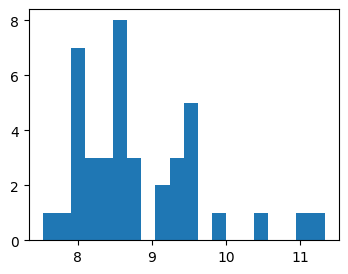

In [10]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.hist(durations, bins=20)

In [7]:

data_dir = Path('/scratch/gilbreth/ahmedb/data/nz/labelled/nwb/')

with NWBHDF5IO(
    data_dir / "speech003.nwb",
    mode='r', load_namespaces=True
) as io:
    nwbfile = io.read()

    audio = nwbfile.acquisition['microphone'].data[()]
    rate = nwbfile.acquisition['microphone'].rate
    trials = nwbfile.trials[:].sort_values('start_time')
    audio_start = trials['start_time'] - 5
    audio_end = trials['stop_time'] - 5

audio = audio.astype(np.float32) / 32768.0 ## convert to float32 and keep within [-1, 1]

Block
Segment 0: Start 0.08s, End 8.67s, Duration 8.59s
Segment 1: Start 18.11s, End 26.60s, Duration 8.49s
Segment 2: Start 36.13s, End 44.80s, Duration 8.67s
Segment 3: Start 54.16s, End 63.47s, Duration 9.31s
Segment 4: Start 72.18s, End 80.34s, Duration 8.16s


NameError: name 'audio' is not defined

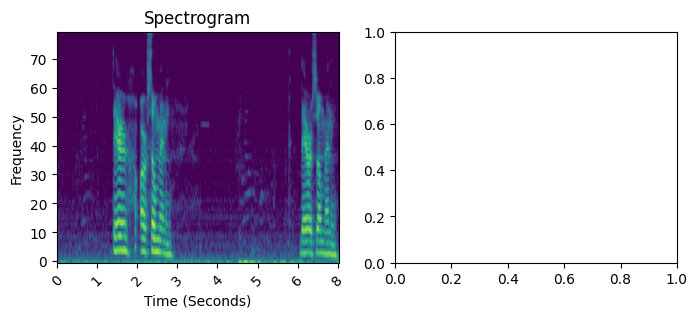

In [25]:
meta = np.load(ds.path / "metadata.npy", allow_pickle=True).item()
# split each trial into 2 segments
ranges = meta['valid_ranges']
print(f"Block")
ranges[:5]
for idx in range(5):
    print(f"Segment {idx}: Start {ranges[idx][0]:.2f}s, End {ranges[idx][-1]:.2f}s, Duration {(ranges[idx][-1]-ranges[idx][0]):.2f}s")

start_time, _, _, end_time = ranges[idx]

spect_strt = int(start_time * ds.fs_spec)
spect_end = int(end_time * ds.fs_spec)

spect = ds.spec_data[:, spect_strt:spect_end].copy()

fig, axes = plt.subplots(1,2, figsize=(8, 3))
ax = axes[0]
ax.imshow(spect.squeeze(), aspect='auto', origin='lower')
ax.set_title('Spectrogram')
ax.set_xlabel('Time (Seconds)')
ax.set_ylabel('Frequency')
ax.set_xticks(np.arange(spect.shape[1])[::100], (np.arange(spect.shape[1])[::100]/ds.fs_spec).astype(int), rotation=45)

ax = axes[1]
clip = audio[int(start_time*rate):int(end_time*rate)] #/ np.max(np.abs(audio[int(start_time*rate):int(end_time*rate)]))
# clip_resampled = scipy.signal.resample(clip, int(clip.shape[0]*22050//rate))
clip_resampled = librosa.resample(clip, orig_sr=rate, target_sr=22050)

mel_spec = librosa.feature.melspectrogram(
        y=clip_resampled, sr=22050, n_fft=1024, 
        hop_length=256, win_length=1024, n_mels=80,
        fmin=0,
        #  fmax=8000, 
        center=False, power=1,
    )

# power_clean = denoise_power_spectrum(mel_spec, method='soft', percentile=50)
# mel_spec = np.sqrt(power_clean)

clip_spect = np.log(np.clip(mel_spec, a_min=1e-5, a_max=None)) 

# clip_spect = processor(torch.tensor(clip_resampled)[None,:].float(), sampling_rate=22050).squeeze().numpy()

ax.imshow(clip_spect.squeeze(), aspect='auto', origin='lower')
ax.set_title('Spectrogram')
ax.set_xlabel('Time (Seconds)')
ax.set_ylabel('Frequency')
ax.set_xticks(np.arange(clip_spect.shape[1])[::100], (np.arange(clip_spect.shape[1])[::100]/ds.fs_spec).astype(int), rotation=45)


plt.tight_layout()
plt.show()

In [11]:
spect.min(), spect.max(), spect.mean(), spect.std()

(np.float32(-11.512925),
 np.float32(1.2930268),
 np.float32(-9.817),
 np.float32(2.5105808))

In [12]:
clip_spect.min(), clip_spect.max(), clip_spect.mean(), clip_spect.std()

(np.float32(-9.964855),
 np.float32(-0.9904952),
 np.float32(-6.9835534),
 np.float32(1.6189065))

In [21]:
with torch.no_grad():
    sh_audio = vocoder(torch.tensor(spect,)[None,:].float().cuda()).detach()
from IPython.display import Audio
Audio(sh_audio.squeeze().cpu().numpy(), rate=22050)

In [29]:
clip_16k = librosa.resample(sh_audio.squeeze().cpu().numpy(), orig_sr=22050, target_sr=16000)
dnsmos.run(clip_16k, sr=16000)

{'ovrl_mos': np.float64(2.644911614647181),
 'sig_mos': np.float64(2.934398390772271),
 'bak_mos': np.float64(4.002804032798546),
 'p808_mos': np.float32(2.9246497)}

In [46]:
with torch.no_grad():
    my_audio = vocoder(torch.tensor(clip_spect,)[None,:].float().cuda()).detach()
from IPython.display import Audio
Audio(my_audio.squeeze().cpu().numpy(), rate=22050)

In [47]:
clip_16k = librosa.resample(my_audio.squeeze().cpu().numpy(), orig_sr=22050, target_sr=16000)
dnsmos.run(clip_16k, sr=16000)

{'ovrl_mos': np.float64(3.166910032436992),
 'sig_mos': np.float64(3.5783641608040027),
 'bak_mos': np.float64(3.9472823926198166),
 'p808_mos': np.float32(3.4005444)}

In [33]:
from IPython.display import Audio
Audio(clip, rate=rate)

In [34]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["ORT_DISABLE_THREAD_AFFINITY"] = "1"  # disables affinity setting entirely

from speechmos import dnsmos
# Resample to 16kHz
clip_16k = librosa.resample(clip, orig_sr=rate, target_sr=16000)
dnsmos.run(clip_16k, sr=16000)

{'ovrl_mos': np.float64(2.814621116498789),
 'sig_mos': np.float64(3.3174837232704584),
 'bak_mos': np.float64(3.734725316254147),
 'p808_mos': np.float32(3.2669165)}

In [15]:
from scipy.signal import butter, filtfilt

def highpass_filter(audio, sr, cutoff=80):
    """Remove DC offset and low-frequency rumble below 80Hz"""
    nyq = sr / 2
    b, a = butter(4, cutoff / nyq, btype='high')
    return filtfilt(b, a, audio)

audio_filtered = highpass_filter(clip, rate, cutoff=80)

from IPython.display import Audio
Audio(audio_filtered, rate=rate)

In [29]:
from scipy.signal import butter, filtfilt

def lowpass_filter(audio, sr, cutoff=10000):
    """Remove high-frequency rumble above 10kHz"""
    nyq = sr / 2
    b, a = butter(4, cutoff / nyq, btype='low')
    return filtfilt(b, a, audio)

audio_filtered = lowpass_filter(clip, rate, cutoff=8000)

from IPython.display import Audio
Audio(audio_filtered, rate=rate)

Text(0, 0.5, 'Amplitude')

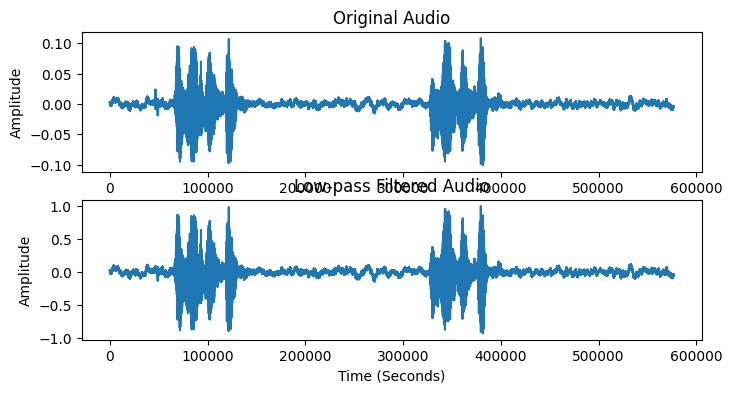

In [43]:
fig, axes = plt.subplots(2,1, figsize=(8, 4))
ax = axes[0]
ax.plot(clip)
ax.set_title('Original Audio')
ax.set_xlabel('Time (Seconds)')
ax.set_ylabel('Amplitude')

ax = axes[1]
ax.plot(audio_filtered)
ax.set_title('Low-pass Filtered Audio')
ax.set_xlabel('Time (Seconds)')
ax.set_ylabel('Amplitude')  


In [35]:
clip_spect.min(), clip_spect.max(), clip_spect.mean(), clip_spect.std()

(np.float32(-7.811575),
 np.float32(1.2393628),
 np.float32(-4.9895353),
 np.float32(1.5289643))

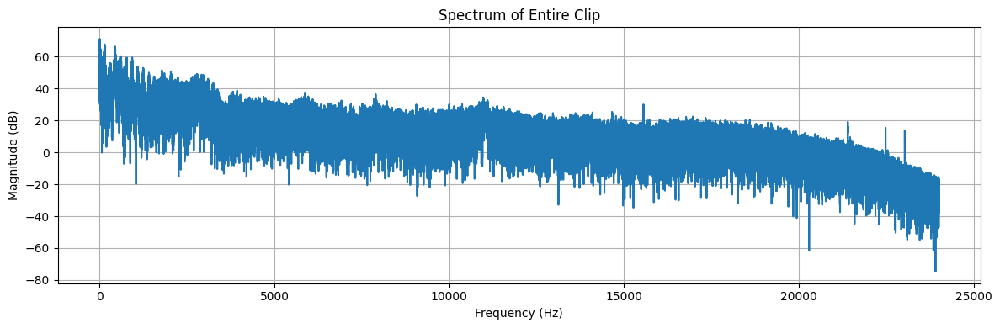

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

# Compute FFT over entire clip
fft = np.fft.rfft(clip)
magnitude = np.abs(fft)
freqs = np.fft.rfftfreq(len(clip), d=1/rate)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(freqs, 20 * np.log10(magnitude + 1e-10))  # dB scale
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.title('Spectrum of Entire Clip')
plt.grid(True)
plt.tight_layout()
plt.show()

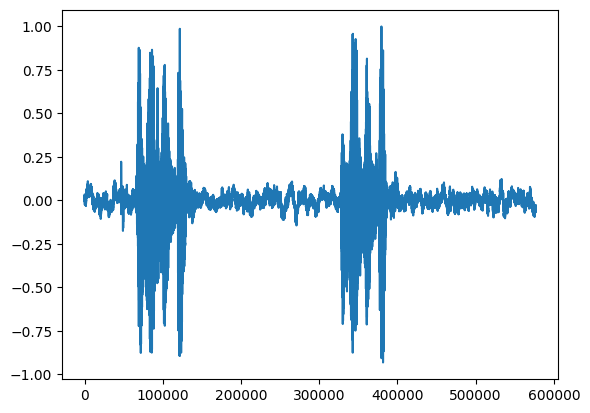

In [28]:
plt.plot(clip)

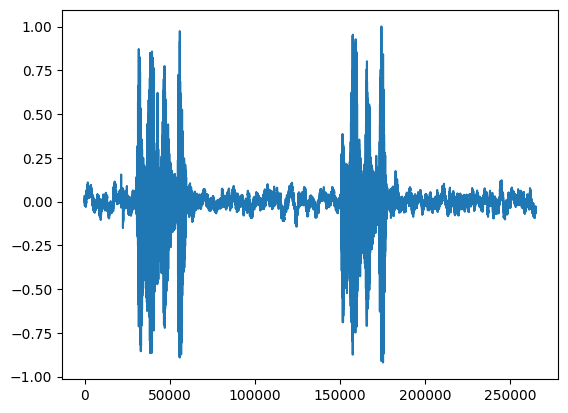

In [30]:
plt.plot(clip_resampled)

In [29]:
from IPython.display import Audio
Audio(clip, rate=rate)

In [20]:
clip_spect.shape

(80, 1034)

In [14]:
clip.shape[0]

576571

In [13]:
rate

np.float64(48000.0)

In [30]:
idx = 3
audio_start.iloc[idx+3] - audio_start.iloc[idx]

np.float64(18.021989199998643)

In [19]:
tr_start = int(audio_start.iloc[0]*rate)
tr_end = int(audio_end.iloc[1]*rate)
tr = audio[tr_start:tr_end]

print(f"trial start: {tr_start}", f"trial end: {tr_end}, number of samples: {len(tr)}")

from IPython.display import Audio
Audio(tr, rate=rate)

trial start: 7606 trial end: 451126, number of samples: 443520


In [10]:
tr = audio[int(audio_start[0]*rate):int(audio_end[1]*rate)]

from IPython.display import Audio
Audio(tr, rate=rate)

In [5]:
audio.shape, rate

((17324160,), np.float64(48000.0))

In [22]:
trials

,start_time,stop_time,transcription,source,production_type
id,,,,,
36,5.158473,10.818473,so right now we are in the middle of nowhere,wav2vec,overt reading
37,12.468473,14.398473,right now we're in the middle of nowhere,wav2vec,overt production
38,14.398473,23.209910,right now we're in the middle of nowhere,wav2vec,covert production
69,23.209909,26.699909,some of them are,prescript,overt reading
70,30.069909,31.329909,some of them are,prescript,overt production
...,...,...,...,...,...
112,696.597635,698.167635,so who do you think you are,prescript,overt production
113,698.167635,707.998843,so who do you think you are,prescript,covert production
114,707.998843,711.598843,thank you both so much,prescript,overt reading


In [23]:
durations = trials['stop_time'] - trials['start_time']
durations.describe()

count    120.000000
mean       5.105980
std        3.185756
min        1.030000
25%        2.207500
50%        4.190000
75%        8.824593
max       10.270104
dtype: float64

### shahed's predictions...

In [2]:
name = "nz_label_predicted"
config = {
    'h5_path': '/scratch/gilbreth/ahmedb/data/nz/train_set.h5',   
    'segment_len': 172
}

data = get_dataset(name, **config)

In [3]:
dataset = data
print(f"Total 2-second segments available: {len(dataset)}")
x, y = dataset[0]
print(f'random input shape : {x.shape}')
print(f'random output shape : {y.shape} ')

Total 2-second segments available: 1560
random input shape : torch.Size([80, 172])
random output shape : torch.Size([80, 172]) 


In [4]:
x, y = dataset[2]

Text(0.5, 1.0, 'True')

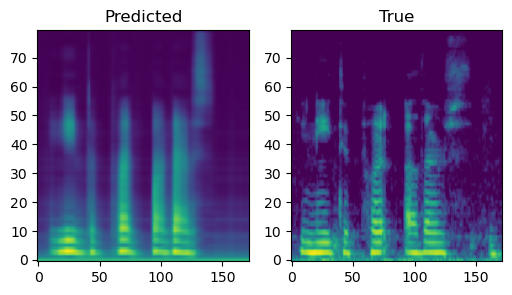

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3))

x, y = dataset[1]
idx=0
axs[idx].imshow(x.squeeze(), aspect='auto', origin='lower')
axs[idx].set_title('Predicted')

idx=1
axs[idx].imshow(y.squeeze(), aspect='auto', origin='lower')
axs[idx].set_title('True')


Text(0.5, 1.0, 'True')

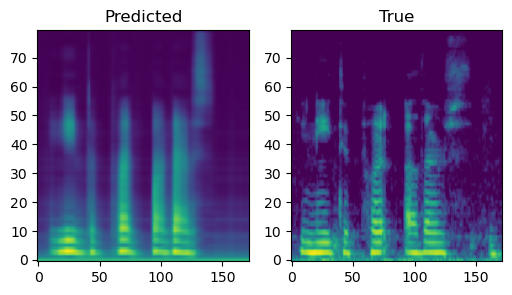

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3))

x, y = dataset[1]
idx=0
axs[idx].imshow(x.squeeze(), aspect='auto', origin='lower')
axs[idx].set_title('Predicted')

idx=1
axs[idx].imshow(y.squeeze(), aspect='auto', origin='lower')
axs[idx].set_title('True')


Text(0.5, 1.0, 'True')

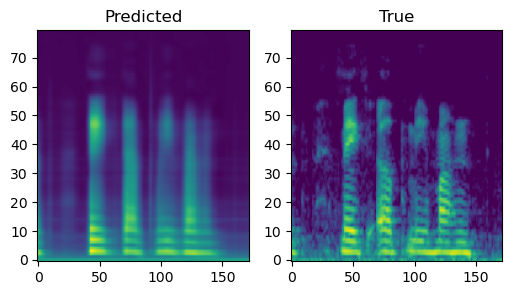

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3))

x, y = dataset[7]
idx=0
axs[idx].imshow(x.squeeze(), aspect='auto', origin='lower')
axs[idx].set_title('Predicted')

idx=1
axs[idx].imshow(y.squeeze(), aspect='auto', origin='lower')
axs[idx].set_title('True')


In [83]:
y.min(), y.max()

(tensor(-11.5129), tensor(0.8704))

In [84]:
y.std(), y.mean()

(tensor(2.5551), tensor(-9.6853))

### pretrained models...

In [35]:
import json
import os
import shutil


class AttrDict(dict):
    def __init__(self, *args, **kwargs):
        super(AttrDict, self).__init__(*args, **kwargs)
        self.__dict__ = self

config_file = '/depot/jgmakin/data/bilal/pretrained_models/hifi-gan/LJ_V1/config.json'
with open(config_file) as f:
    data = f.read()

json_config = json.loads(data)
h = AttrDict(json_config)

In [36]:
from models import Generator

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

generator = Generator(h)

hifi_checkpoint = '/depot/jgmakin/data/bilal/pretrained_models/hifi-gan/LJ_V1/generator_v1'
state_dict_g = torch.load(hifi_checkpoint, map_location='cpu')
generator.load_state_dict(state_dict_g['generator'])

generator.eval()
generator = generator.to(device)

/depot/jgmakin/data/bilal/env/diffusion/lib/python3.8/site-packages/torch/nn/utils/weight_norm.py:134: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/tmp/ipykernel_561347/3107449779.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weight

In [23]:
wavs = generator(torch.stack([x,y], dim=0).cuda()).detach()

In [46]:
import torchaudio
import torch

def write_wav(tensor, path, sample_rate=22050):
    # ensure 2D tensor (channels, samples)
    if tensor.dim() == 1:
        tensor = tensor.unsqueeze(0)
    torchaudio.save(path, tensor.cpu(), sample_rate)

def read_wav(path):
    tensor, sample_rate = torchaudio.load(path)
    return tensor.squeeze(), sample_rate  # returns (tensor, sr)

In [48]:

write_wav(wavs[1], "bad_audio.wav")

# # Read
# tensor, sr = read_wav("output.wav")

In [ ]:
from pydub import AudioSegment
from pydub.effects import high_pass_filter, low_pass_filter

# audio = AudioSegment.from_wav("your_audio.wav")
audio = y
filtered = high_pass_filter(audio, cutoff=300)  # remove low rumble

In [29]:
wavs[0].min(), wavs[0].max()

(tensor(-0.2553, device='cuda:0'), tensor(0.1172, device='cuda:0'))

In [30]:
import numpy as np
from pydub import AudioSegment
from pydub.effects import high_pass_filter

def enhance_tensor_audio(tensor, sample_rate=22050):
    # Convert pytorch tensor to numpy
    audio_np = tensor.squeeze().cpu().numpy()
    
    # Normalize to int16 range (pydub expects int16 PCM)
    audio_int16 = (audio_np * 32767).astype(np.int16)
    
    # Convert to pydub AudioSegment
    audio_segment = AudioSegment(
        audio_int16.tobytes(),
        frame_rate=sample_rate,
        sample_width=2,  # 2 bytes = int16
        channels=1
    )
    
    # Apply high pass filter
    filtered = high_pass_filter(audio_segment, cutoff=300)
    
    # Convert back to pytorch tensor
    filtered_np = np.frombuffer(filtered.raw_data, dtype=np.int16).astype(np.float32) / 32767
    output_tensor = torch.tensor(filtered_np)
    
    return output_tensor

In [40]:
import numpy as np
import torch
from scipy import signal

def enhance_audio(tensor, sample_rate=22050):
    # Convert to numpy
    audio_np = tensor.squeeze().cpu().numpy()
    
    # High pass filter at 300Hz (removes low rumble)
    sos_high = signal.butter(6, 300, btype='high', fs=sample_rate, output='sos')
    audio_np = signal.sosfilt(sos_high, audio_np)
    
    # Boost intelligibility frequencies (1k-4kHz) using a bandpass boost
    sos_band = signal.butter(4, [1000, 4000], btype='band', fs=sample_rate, output='sos')
    boosted = signal.sosfilt(sos_band, audio_np)
    audio_np = audio_np + 0.5 * boosted  # mix in the boost
    
    # Normalize back to [-1, 1]
    audio_np = audio_np / np.abs(audio_np).max()
    
    return torch.tensor(audio_np, dtype=torch.float32)

In [41]:
# Normalize first if needed
audio_tensor = wavs[0]
audio_tensor = audio_tensor / audio_tensor.abs().max()

In [42]:
enhanced = enhance_audio(audio_tensor)

In [37]:
hifi = get_processor("hifi")

In [44]:
spect = hifi(enhanced.cpu().unsqueeze(0))

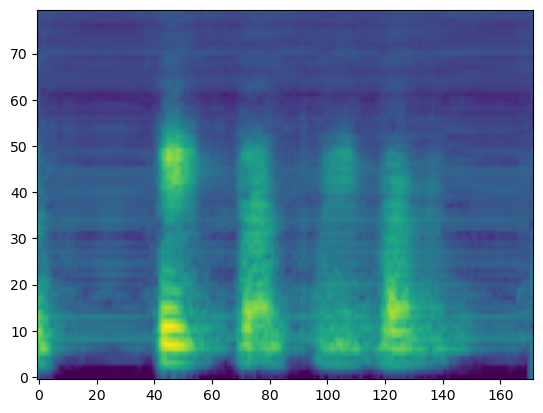

In [45]:
plt.imshow(spect.cpu().squeeze(), aspect='auto', origin='lower')

In [43]:
from IPython.display import Audio
Audio(enhanced.cpu().squeeze(), rate=22050)

In [25]:
from IPython.display import Audio
Audio(wavs[0].cpu().squeeze(), rate=22050)

In [26]:
from IPython.display import Audio
Audio(wavs[1].cpu().squeeze(), rate=22050)

### nz_label

In [6]:
def dynamic_range_decompression_torch(x, C=1):
    return torch.exp(x) / C

Block
Segment 0: Start 0.15s, End 6.19s, Duration 6.04s
Segment 1: Start 9.21s, End 15.22s, Duration 6.02s
Segment 2: Start 18.23s, End 24.24s, Duration 6.01s
Segment 3: Start 27.25s, End 33.26s, Duration 6.01s
Segment 4: Start 36.27s, End 42.28s, Duration 6.01s


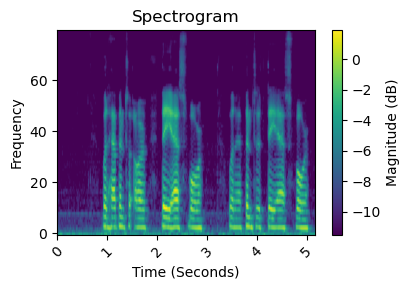

In [27]:
name = "nz_label"
block_id = 1
config = {
    'root_dir': '/scratch/gilbreth/ahmedb/data/nz/labelled/processed_blocks/',
    'block_ids': [block_id],
    'trial_duration': 4,
    'mode': 'train'
}
ds = get_dataset(name, **config)

meta = np.load(ds.path / "metadata.npy", allow_pickle=True).item()
# split each trial into 2 segments
ranges = meta['valid_ranges']
print(f"Block")
ranges[:5]
for idx in range(5):
    print(f"Segment {idx}: Start {ranges[idx][0]:.2f}s, End {ranges[idx][1]:.2f}s, Duration {(ranges[idx][1]-ranges[idx][0]):.2f}s")

start_time, end_time = ranges[idx]

spect_strt = int(start_time * ds.fs_spec)
spect_end = int(end_time * ds.fs_spec)

spect = ds.spec_data[:, spect_strt:spect_end].copy()

fig, ax = plt.subplots(figsize=(4, 3))
plt.imshow(spect.squeeze(), aspect='auto', origin='lower')
ax.set_title('Spectrogram')
ax.set_xlabel('Time (Seconds)')
ax.set_ylabel('Frequency')
plt.xticks(np.arange(spect.shape[1])[::100], (np.arange(spect.shape[1])[::100]/ds.fs_spec).astype(int), rotation=45)
plt.tight_layout()  
plt.colorbar(label='Magnitude (dB)')
plt.show()

Block
Segment 0: Start 0.14s, End 12.18s, Duration 12.03s
Segment 1: Start 18.19s, End 30.21s, Duration 12.01s
Segment 2: Start 36.22s, End 48.23s, Duration 12.01s
Segment 3: Start 54.24s, End 66.25s, Duration 12.01s
Segment 4: Start 72.26s, End 84.27s, Duration 12.01s


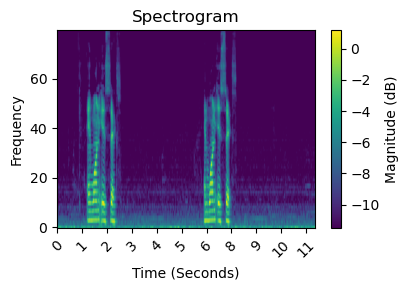

In [29]:
name = "nz_label"
block_id = 3
config = {
    'root_dir': '/scratch/gilbreth/ahmedb/data/nz/labelled/processed_blocks/',
    'block_ids': [block_id],
    'trial_duration': 4,
    'mode': 'train'
}
ds = get_dataset(name, **config)

meta = np.load(ds.path / "metadata.npy", allow_pickle=True).item()
# split each trial into 2 segments
ranges = meta['valid_ranges']
print(f"Block")
ranges[:5]
for idx in range(5):
    print(f"Segment {idx}: Start {ranges[idx][0]:.2f}s, End {ranges[idx][1]:.2f}s, Duration {(ranges[idx][1]-ranges[idx][0]):.2f}s")

start_time, end_time = ranges[idx]

spect_strt = int(start_time * ds.fs_spec)
spect_end = int(end_time * ds.fs_spec)

spect = ds.spec_data[:, spect_strt:spect_end].copy()

fig, ax = plt.subplots(figsize=(4, 3))
plt.imshow(spect.squeeze(), aspect='auto', origin='lower')
ax.set_title('Spectrogram')
ax.set_xlabel('Time (Seconds)')
ax.set_ylabel('Frequency')
plt.xticks(np.arange(spect.shape[1])[::100], (np.arange(spect.shape[1])[::100]/ds.fs_spec).astype(int), rotation=45)
plt.tight_layout()  
plt.colorbar(label='Magnitude (dB)')
plt.show()

Block
Segment 0: Start 0.07s, End 12.09s, Duration 12.02s
Segment 1: Start 18.10s, End 30.11s, Duration 12.01s
Segment 2: Start 36.12s, End 48.14s, Duration 12.02s
Segment 3: Start 54.14s, End 66.16s, Duration 12.01s
Segment 4: Start 72.17s, End 84.18s, Duration 12.02s


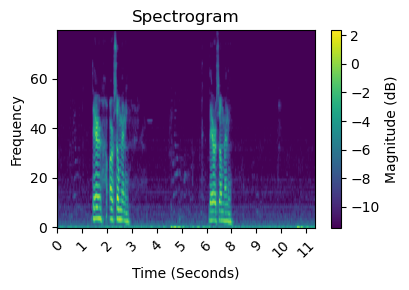

In [28]:
name = "nz_label"
block_id = 4
config = {
    'root_dir': '/scratch/gilbreth/ahmedb/data/nz/labelled/processed_blocks/',
    'block_ids': [block_id],
    'trial_duration': 4,
    'mode': 'train'
}
ds = get_dataset(name, **config)

meta = np.load(ds.path / "metadata.npy", allow_pickle=True).item()
# split each trial into 2 segments
ranges = meta['valid_ranges']
print(f"Block")
ranges[:5]
for idx in range(5):
    print(f"Segment {idx}: Start {ranges[idx][0]:.2f}s, End {ranges[idx][1]:.2f}s, Duration {(ranges[idx][1]-ranges[idx][0]):.2f}s")

start_time, end_time = ranges[idx]

spect_strt = int(start_time * ds.fs_spec)
spect_end = int(end_time * ds.fs_spec)

spect = ds.spec_data[:, spect_strt:spect_end].copy()

fig, ax = plt.subplots(figsize=(4, 3))
plt.imshow(spect.squeeze(), aspect='auto', origin='lower')
ax.set_title('Spectrogram')
ax.set_xlabel('Time (Seconds)')
ax.set_ylabel('Frequency')
plt.xticks(np.arange(spect.shape[1])[::100], (np.arange(spect.shape[1])[::100]/ds.fs_spec).astype(int), rotation=45)
plt.tight_layout()  
plt.colorbar(label='Magnitude (dB)')
plt.show()

Block
Segment 0: Start 0.10s, End 12.12s, Duration 12.02s
Segment 1: Start 18.13s, End 30.14s, Duration 12.01s
Segment 2: Start 36.15s, End 48.17s, Duration 12.02s
Segment 3: Start 54.18s, End 66.19s, Duration 12.01s
Segment 4: Start 72.20s, End 84.21s, Duration 12.02s


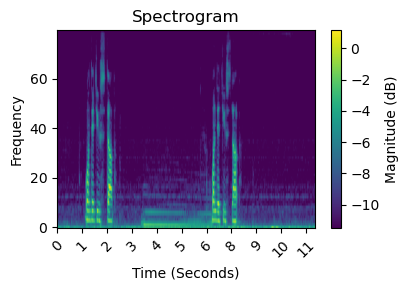

In [30]:
name = "nz_label"
block_id = 5
config = {
    'root_dir': '/scratch/gilbreth/ahmedb/data/nz/labelled/processed_blocks/',
    'block_ids': [block_id],
    'trial_duration': 4,
    'mode': 'train'
}
ds = get_dataset(name, **config)

meta = np.load(ds.path / "metadata.npy", allow_pickle=True).item()
# split each trial into 2 segments
ranges = meta['valid_ranges']
print(f"Block")
ranges[:5]
for idx in range(5):
    print(f"Segment {idx}: Start {ranges[idx][0]:.2f}s, End {ranges[idx][1]:.2f}s, Duration {(ranges[idx][1]-ranges[idx][0]):.2f}s")

start_time, end_time = ranges[idx]

spect_strt = int(start_time * ds.fs_spec)
spect_end = int(end_time * ds.fs_spec)

spect = ds.spec_data[:, spect_strt:spect_end].copy()

fig, ax = plt.subplots(figsize=(4, 3))
plt.imshow(spect.squeeze(), aspect='auto', origin='lower')
ax.set_title('Spectrogram')
ax.set_xlabel('Time (Seconds)')
ax.set_ylabel('Frequency')
plt.xticks(np.arange(spect.shape[1])[::100], (np.arange(spect.shape[1])[::100]/ds.fs_spec).astype(int), rotation=45)
plt.tight_layout()  
plt.colorbar(label='Magnitude (dB)')
plt.show()

Block
Segment 0: Start 0.09s, End 12.11s, Duration 12.02s
Segment 1: Start 18.13s, End 30.14s, Duration 12.01s
Segment 2: Start 36.14s, End 48.16s, Duration 12.01s
Segment 3: Start 54.16s, End 66.18s, Duration 12.01s
Segment 4: Start 72.18s, End 84.19s, Duration 12.01s


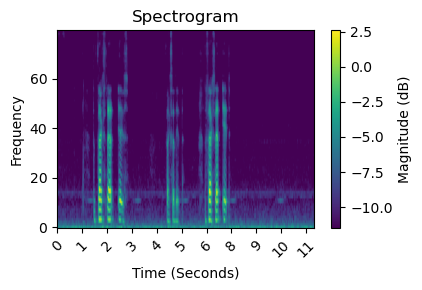

In [31]:
name = "nz_label"
block_id = 6
config = {
    'root_dir': '/scratch/gilbreth/ahmedb/data/nz/labelled/processed_blocks/',
    'block_ids': [block_id],
    'trial_duration': 4,
    'mode': 'train'
}
ds = get_dataset(name, **config)

meta = np.load(ds.path / "metadata.npy", allow_pickle=True).item()
# split each trial into 2 segments
ranges = meta['valid_ranges']
print(f"Block")
ranges[:5]
for idx in range(5):
    print(f"Segment {idx}: Start {ranges[idx][0]:.2f}s, End {ranges[idx][1]:.2f}s, Duration {(ranges[idx][1]-ranges[idx][0]):.2f}s")

start_time, end_time = ranges[idx]

spect_strt = int(start_time * ds.fs_spec)
spect_end = int(end_time * ds.fs_spec)

spect = ds.spec_data[:, spect_strt:spect_end].copy()

fig, ax = plt.subplots(figsize=(4, 3))
plt.imshow(spect.squeeze(), aspect='auto', origin='lower')
ax.set_title('Spectrogram')
ax.set_xlabel('Time (Seconds)')
ax.set_ylabel('Frequency')
plt.xticks(np.arange(spect.shape[1])[::100], (np.arange(spect.shape[1])[::100]/ds.fs_spec).astype(int), rotation=45)
plt.tight_layout()  
plt.colorbar(label='Magnitude (dB)')
plt.show()

Block
Segment 0: Start 0.09s, End 12.12s, Duration 12.03s
Segment 1: Start 18.13s, End 30.15s, Duration 12.02s
Segment 2: Start 36.15s, End 48.17s, Duration 12.02s
Segment 3: Start 54.18s, End 66.19s, Duration 12.02s
Segment 4: Start 72.20s, End 84.22s, Duration 12.01s


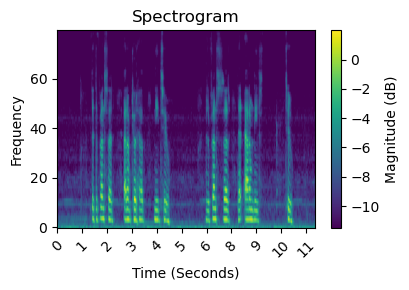

In [32]:
name = "nz_label"
block_id = 7
config = {
    'root_dir': '/scratch/gilbreth/ahmedb/data/nz/labelled/processed_blocks/',
    'block_ids': [block_id],
    'trial_duration': 4,
    'mode': 'train'
}
ds = get_dataset(name, **config)

meta = np.load(ds.path / "metadata.npy", allow_pickle=True).item()
# split each trial into 2 segments
ranges = meta['valid_ranges']
print(f"Block")
ranges[:5]
for idx in range(5):
    print(f"Segment {idx}: Start {ranges[idx][0]:.2f}s, End {ranges[idx][1]:.2f}s, Duration {(ranges[idx][1]-ranges[idx][0]):.2f}s")

start_time, end_time = ranges[idx]

spect_strt = int(start_time * ds.fs_spec)
spect_end = int(end_time * ds.fs_spec)

spect = ds.spec_data[:, spect_strt:spect_end].copy()

fig, ax = plt.subplots(figsize=(4, 3))
plt.imshow(spect.squeeze(), aspect='auto', origin='lower')
ax.set_title('Spectrogram')
ax.set_xlabel('Time (Seconds)')
ax.set_ylabel('Frequency')
plt.xticks(np.arange(spect.shape[1])[::100], (np.arange(spect.shape[1])[::100]/ds.fs_spec).astype(int), rotation=45)
plt.tight_layout()  
plt.colorbar(label='Magnitude (dB)')
plt.show()

Block
Segment 0: Start 0.11s, End 12.13s, Duration 12.02s
Segment 1: Start 18.14s, End 30.15s, Duration 12.01s
Segment 2: Start 36.16s, End 48.17s, Duration 12.01s
Segment 3: Start 54.18s, End 66.19s, Duration 12.02s
Segment 4: Start 72.20s, End 84.22s, Duration 12.01s


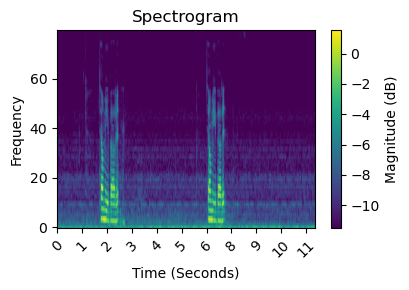

In [33]:
name = "nz_label"
block_id = 8
config = {
    'root_dir': '/scratch/gilbreth/ahmedb/data/nz/labelled/processed_blocks/',
    'block_ids': [block_id],
    'trial_duration': 4,
    'mode': 'train'
}
ds = get_dataset(name, **config)

meta = np.load(ds.path / "metadata.npy", allow_pickle=True).item()
# split each trial into 2 segments
ranges = meta['valid_ranges']
print(f"Block")
ranges[:5]
for idx in range(5):
    print(f"Segment {idx}: Start {ranges[idx][0]:.2f}s, End {ranges[idx][1]:.2f}s, Duration {(ranges[idx][1]-ranges[idx][0]):.2f}s")

start_time, end_time = ranges[idx]

spect_strt = int(start_time * ds.fs_spec)
spect_end = int(end_time * ds.fs_spec)

spect = ds.spec_data[:, spect_strt:spect_end].copy()

fig, ax = plt.subplots(figsize=(4, 3))
plt.imshow(spect.squeeze(), aspect='auto', origin='lower')
ax.set_title('Spectrogram')
ax.set_xlabel('Time (Seconds)')
ax.set_ylabel('Frequency')
plt.xticks(np.arange(spect.shape[1])[::100], (np.arange(spect.shape[1])[::100]/ds.fs_spec).astype(int), rotation=45)
plt.tight_layout()  
plt.colorbar(label='Magnitude (dB)')
plt.show()

Block
Segment 0: Start 0.09s, End 12.11s, Duration 12.03s
Segment 1: Start 18.13s, End 30.15s, Duration 12.02s
Segment 2: Start 36.15s, End 48.17s, Duration 12.02s
Segment 3: Start 54.18s, End 66.20s, Duration 12.02s
Segment 4: Start 72.20s, End 84.22s, Duration 12.02s


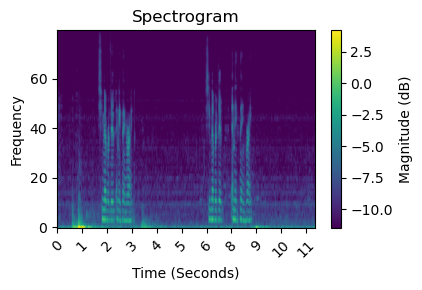

In [34]:
name = "nz_label"
block_id = 9
config = {
    'root_dir': '/scratch/gilbreth/ahmedb/data/nz/labelled/processed_blocks/',
    'block_ids': [block_id],
    'trial_duration': 4,
    'mode': 'train'
}
ds = get_dataset(name, **config)

meta = np.load(ds.path / "metadata.npy", allow_pickle=True).item()
# split each trial into 2 segments
ranges = meta['valid_ranges']
print(f"Block")
ranges[:5]
for idx in range(5):
    print(f"Segment {idx}: Start {ranges[idx][0]:.2f}s, End {ranges[idx][1]:.2f}s, Duration {(ranges[idx][1]-ranges[idx][0]):.2f}s")

start_time, end_time = ranges[idx]

spect_strt = int(start_time * ds.fs_spec)
spect_end = int(end_time * ds.fs_spec)

spect = ds.spec_data[:, spect_strt:spect_end].copy()

fig, ax = plt.subplots(figsize=(4, 3))
plt.imshow(spect.squeeze(), aspect='auto', origin='lower')
ax.set_title('Spectrogram')
ax.set_xlabel('Time (Seconds)')
ax.set_ylabel('Frequency')
plt.xticks(np.arange(spect.shape[1])[::100], (np.arange(spect.shape[1])[::100]/ds.fs_spec).astype(int), rotation=45)
plt.tight_layout()  
plt.colorbar(label='Magnitude (dB)')
plt.show()

#### block-1 trials...

In [48]:
name = "nz_label"
block_id = 1
config = {
    'root_dir': '/scratch/gilbreth/ahmedb/data/nz/labelled/processed_blocks/',
    'block_ids': [block_id],
    'trial_duration': 4,
    'mode': 'train'
}
ds = get_dataset(name, **config)

meta = np.load(ds.path / "metadata.npy", allow_pickle=True).item()
# split each trial into 2 segments
ranges = meta['valid_ranges']
print(f"Block")
ranges[:5]
for idx in range(5):
    print(f"Segment {idx}: Start {ranges[idx][0]:.2f}s, End {ranges[idx][1]:.2f}s, Duration {(ranges[idx][1]-ranges[idx][0]):.2f}s")



Block
Segment 0: Start 0.15s, End 6.19s, Duration 6.04s
Segment 1: Start 9.21s, End 15.22s, Duration 6.02s
Segment 2: Start 18.23s, End 24.24s, Duration 6.01s
Segment 3: Start 27.25s, End 33.26s, Duration 6.01s
Segment 4: Start 36.27s, End 42.28s, Duration 6.01s


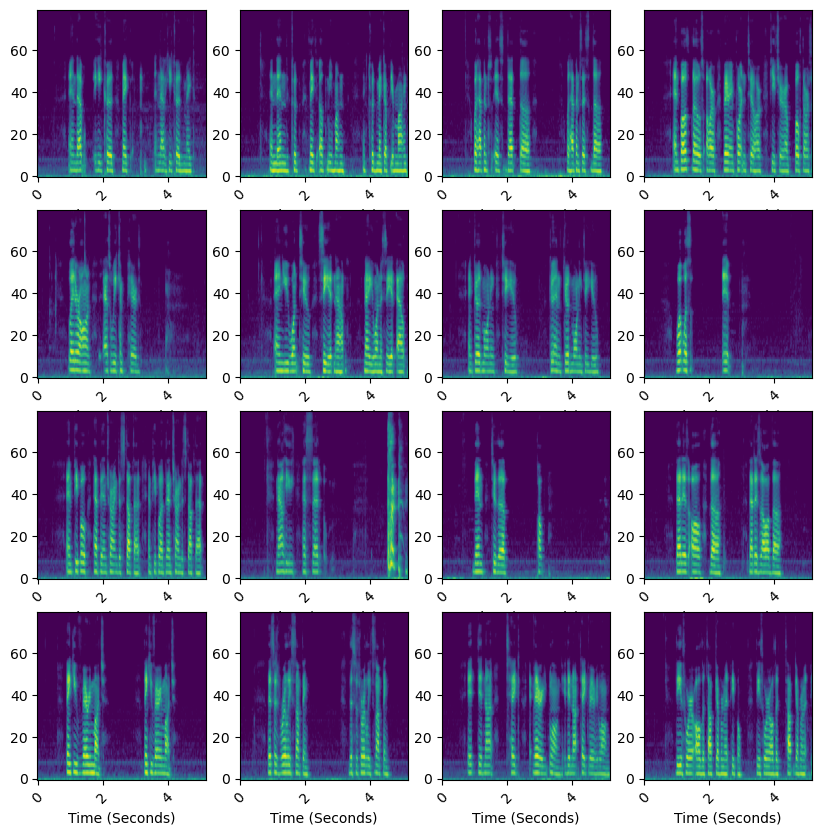

In [49]:
num_examples = 16
rng = np.random.default_rng(seed=42)
ranges = rng.choice(ranges, size=num_examples, replace=False)
# ranges = np.random.shuffle(ranges)
fig, axes = plt.subplots(4,4,figsize=(10, 10))
axes = axes.flatten()
tick_step = 200
for idx in range(num_examples):

    start_time, end_time = ranges[idx]

    spect_strt = int(start_time * ds.fs_spec)
    spect_end = int(end_time * ds.fs_spec)

    spect = ds.spec_data[:, spect_strt:spect_end].copy()

    ax = axes[idx]
    ax.imshow(spect.squeeze(), aspect='auto', origin='lower')
    # ax.set_title('Spectrogram')
    ax.set_xlabel('Time (Seconds)')
    # ax.set_ylabel('Frequency')
    ax.set_xticks(np.arange(spect.shape[1])[::tick_step], (np.arange(spect.shape[1])[::tick_step]/ds.fs_spec).astype(int), rotation=45)

#### block-3

In [ ]:
name = "nz_label"
block_id = 3
config = {
    'root_dir': '/scratch/gilbreth/ahmedb/data/nz/labelled/processed_blocks/',
    'block_ids': [block_id],
    'trial_duration': 4,
    'mode': 'train'
}
ds = get_dataset(name, **config)

meta = np.load(ds.path / "metadata.npy", allow_pickle=True).item()
# split each trial into 2 segments
ranges = meta['valid_ranges']

Block
Segment 0: Start 0.14s, End 12.18s, Duration 12.03s
Segment 1: Start 18.19s, End 30.21s, Duration 12.01s
Segment 2: Start 36.22s, End 48.23s, Duration 12.01s
Segment 3: Start 54.24s, End 66.25s, Duration 12.01s
Segment 4: Start 72.26s, End 84.27s, Duration 12.01s


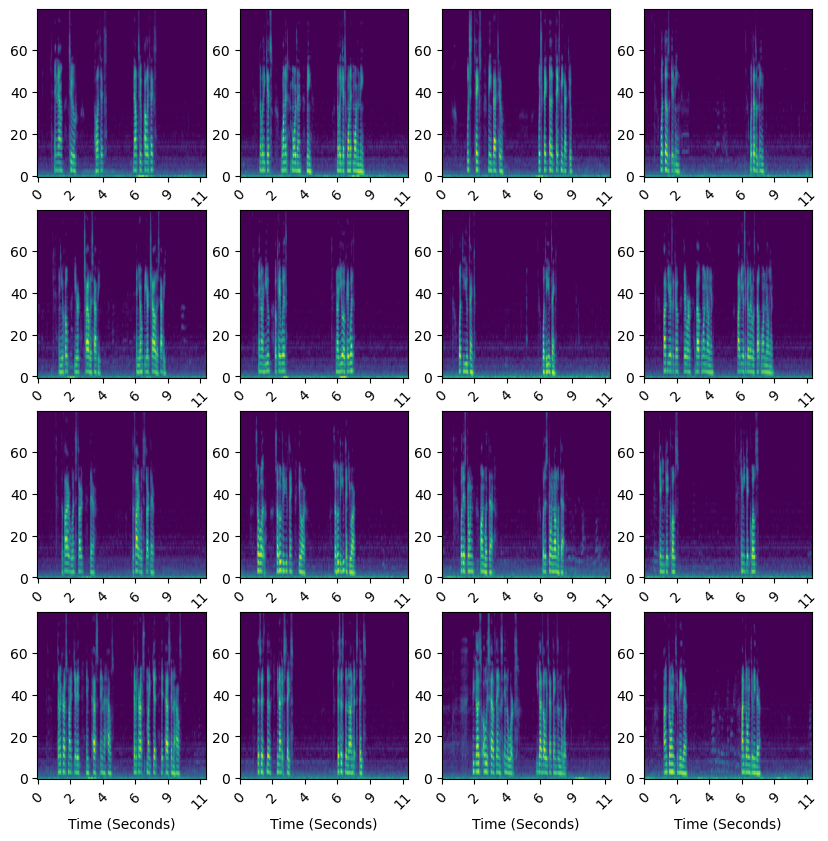

In [ ]:
num_examples = 16
rng = np.random.default_rng(seed=42)
ranges = rng.choice(ranges, size=num_examples, replace=False)
# ranges = np.random.shuffle(ranges)
fig, axes = plt.subplots(4,4,figsize=(10, 10))
axes = axes.flatten()
tick_step = 200
for idx in range(num_examples):

    start_time, end_time = ranges[idx]

    spect_strt = int(start_time * ds.fs_spec)
    spect_end = int(end_time * ds.fs_spec)

    spect = ds.spec_data[:, spect_strt:spect_end].copy()

    ax = axes[idx]
    ax.imshow(spect.squeeze(), aspect='auto', origin='lower')
    # ax.set_title('Spectrogram')
    ax.set_xlabel('Time (Seconds)')
    ax.set_xticks(np.arange(spect.shape[1])[::tick_step], (np.arange(spect.shape[1])[::tick_step]/ds.fs_spec).astype(int), rotation=45)

#### block-4

In [ ]:
name = "nz_label"
block_id = 4
config = {
    'root_dir': '/scratch/gilbreth/ahmedb/data/nz/labelled/processed_blocks/',
    'block_ids': [block_id],
    'trial_duration': 4,
    'mode': 'train'
}
ds = get_dataset(name, **config)

meta = np.load(ds.path / "metadata.npy", allow_pickle=True).item()
# split each trial into 2 segments
ranges = meta['valid_ranges']

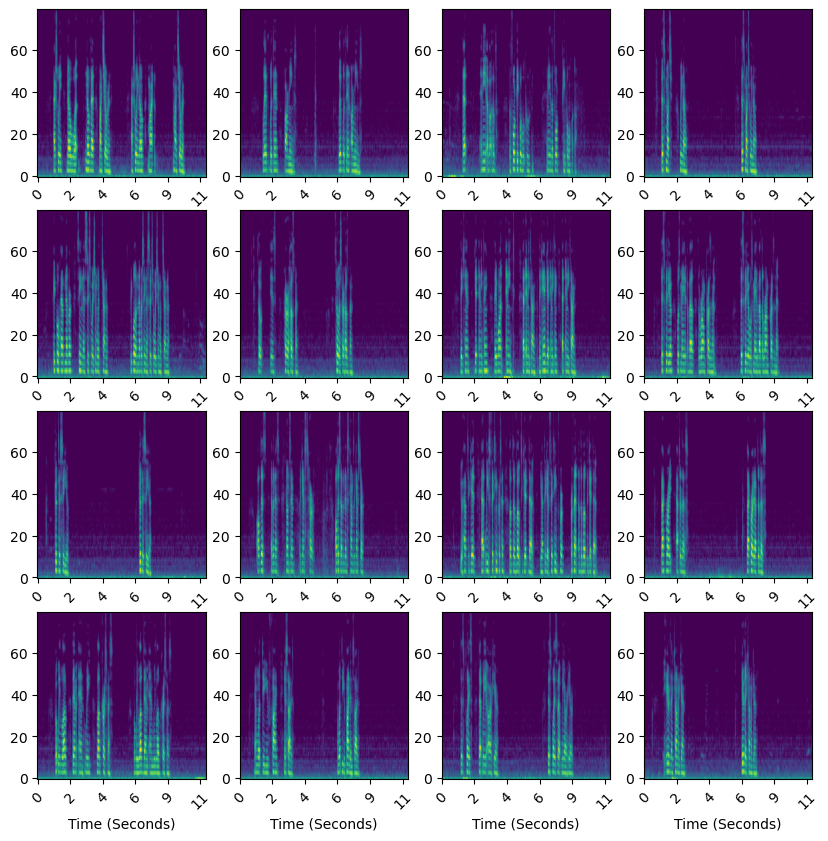

In [ ]:
num_examples = 16
rng = np.random.default_rng(seed=42)
ranges = rng.choice(ranges, size=num_examples, replace=False)
# ranges = np.random.shuffle(ranges)
fig, axes = plt.subplots(4,4,figsize=(10, 10))
axes = axes.flatten()
tick_step = 200
for idx in range(num_examples):

    start_time, end_time = ranges[idx]

    spect_strt = int(start_time * ds.fs_spec)
    spect_end = int(end_time * ds.fs_spec)

    spect = ds.spec_data[:, spect_strt:spect_end].copy()

    ax = axes[idx]
    ax.imshow(spect.squeeze(), aspect='auto', origin='lower')
    ax.set_xlabel('Time (Seconds)')
    ax.set_xticks(np.arange(spect.shape[1])[::tick_step], (np.arange(spect.shape[1])[::tick_step]/ds.fs_spec).astype(int), rotation=45)


#### block-5

In [46]:
name = "nz_label"
block_id = 5
config = {
    'root_dir': '/scratch/gilbreth/ahmedb/data/nz/labelled/processed_blocks/',
    'block_ids': [block_id],
    'trial_duration': 4,
    'mode': 'train'
}
ds = get_dataset(name, **config)

meta = np.load(ds.path / "metadata.npy", allow_pickle=True).item()
# split each trial into 2 segments
ranges = meta['valid_ranges']


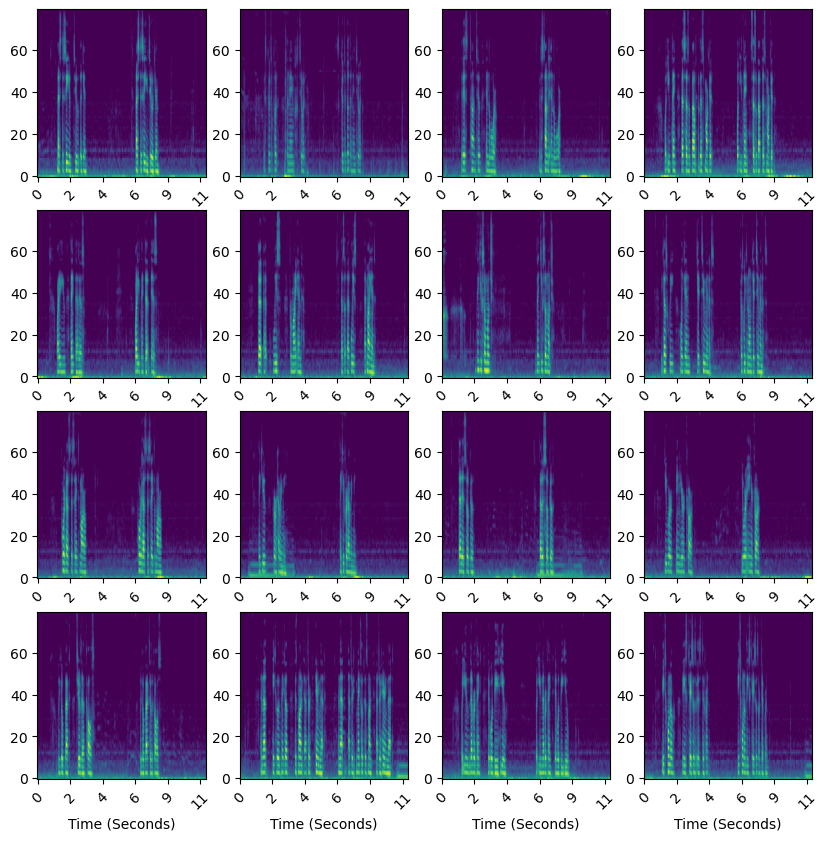

In [47]:
num_examples = 16
rng = np.random.default_rng(seed=42)
ranges = rng.choice(ranges, size=num_examples, replace=False)
# ranges = np.random.shuffle(ranges)
fig, axes = plt.subplots(4,4,figsize=(10, 10))
axes = axes.flatten()
tick_step = 200
for idx in range(num_examples):

    start_time, end_time = ranges[idx]

    spect_strt = int(start_time * ds.fs_spec)
    spect_end = int(end_time * ds.fs_spec)

    spect = ds.spec_data[:, spect_strt:spect_end].copy()

    ax = axes[idx]
    ax.imshow(spect.squeeze(), aspect='auto', origin='lower')
    ax.set_xlabel('Time (Seconds)')
    ax.set_xticks(np.arange(spect.shape[1])[::tick_step], (np.arange(spect.shape[1])[::tick_step]/ds.fs_spec).astype(int), rotation=45)


In [ ]:
spect = spec_data[:, spect_slice[0] : spect_slice[0]+spect_slice[1]].copy()  # copy to avoid mmap issues

[[0.15334359998814762, 6.190621933327444],
 [9.209261099997093, 15.224674166660407],
 [18.232380699992063, 24.243648766661256],
 [27.249282799995854, 33.260655466666016],
 [36.2663418000011, 42.27916299999439]]

In [ ]:
start_time, end_time = self.ranges[idx]
eeg_slice, spect_slice = self.get_start_win_samples(start_time, end_time - start_time)
x = self.eeg_data[:, eeg_slice[0] : eeg_slice[0]+eeg_slice[1]].copy()  # copy to avoid mmap issues
y = self.spec_data[:, spect_slice[0] : spect_slice[0]+spect_slice[1]].copy()  # copy to avoid mmap issues

In [7]:
idx = 3
eeg, spect = ds[idx]
print(f"EEG shape: {eeg.shape}, Spectrogram shape: {spect.shape}") 

print(f"Spectrogram stats \n\tmin: {spect.min():.3f}, \n \tmax: {spect.max():.3f}, \n \tstd: {spect.std():.3f}, \n \tmean: {spect.mean():.3f}")
spect = (spect+4.5) / 7.5 
print(f"Normalized spectrogram stats \n\tmin: {spect.min():.3f}, \n \tmax: {spect.max():.3f}, \n \tstd: {spect.std():.3f}, \n \tmean: {spect.mean():.3f}")


EEG shape: torch.Size([508, 800]), Spectrogram shape: torch.Size([80, 344])
Spectrogram stats 
	min: -11.513, 
 	max: 2.990, 
 	std: 3.477, 
 	mean: -8.214
Normalized spectrogram stats 
	min: -0.935, 
 	max: 0.999, 
 	std: 0.464, 
 	mean: -0.495


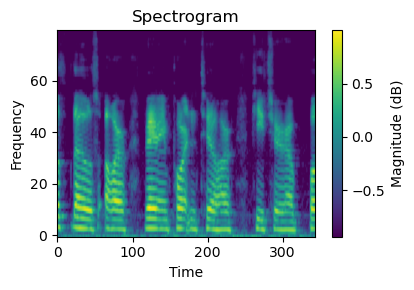

In [8]:
fig, ax = plt.subplots(figsize=(4, 3))

plt.imshow(spect.cpu().squeeze(), aspect='auto', origin='lower')
ax.set_title('Spectrogram')
ax.set_xlabel('Time')
ax.set_ylabel('Frequency')
plt.tight_layout()  
plt.colorbar(label='Magnitude (dB)')
plt.show()

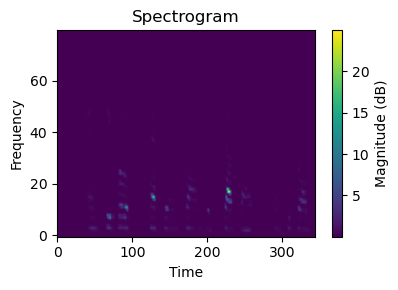

In [7]:
fig, ax = plt.subplots(figsize=(4, 3))

spect_decom = dynamic_range_decompression_torch(spect.cpu().squeeze(), C=1)  # Adjust C as needed for scaling

plt.imshow(spect_decom.cpu().squeeze(), aspect='auto', origin='lower')
ax.set_title('Spectrogram')
ax.set_xlabel('Time')
ax.set_ylabel('Frequency')
plt.tight_layout()  
plt.colorbar(label='Magnitude (dB)')
plt.show()

### Training setup...

In [3]:
config_path = '/home/ahmedb/projects/diffusion-hub/configs/train_configs/eeg_to_speech.yaml'
args = OmegaConf.load(config_path)

In [4]:
train_config = args.data.train_data
train_ds = get_dataset(train_config.name, **train_config.dataset_config)

val_config = args.data.val_data
val_ds = get_dataset(val_config.name, **val_config.dataset_config)

In [6]:
idx = 17
eeg, spect = val_ds[idx]
print(f"EEG shape: {eeg.shape}, Spectrogram shape: {spect.shape}")

EEG shape: torch.Size([508, 1200]), Spectrogram shape: torch.Size([80, 516])


In [59]:
idx=16
start_time, end_time = val_ds.ranges[idx]

print(f"Segment duration: {(end_time*val_ds.fs_spec - start_time*val_ds.fs_spec):.2f} samples")
print(f"Segment duration: {int(end_time*val_ds.fs_spec) - int(start_time*val_ds.fs_spec)} samples")

print(f"Segment start time: {start_time:.2f} seconds, Segment end time: {end_time:.2f} seconds")
print(f"Segment duration: {(end_time - start_time):.2f} seconds")
print(f"Segment duration: {(end_time - start_time)*val_ds.fs_spec:.2f} samples")


Segment duration: 516.80 samples
Segment duration: 517 samples
Segment start time: 653.92 seconds, Segment end time: 659.92 seconds
Segment duration: 6.00 seconds
Segment duration: 516.80 samples


In [48]:
int(6*val_ds.fs_spec)

516

In [26]:
val_ds.ranges[0]

val_ds.ranges[0][1] - val_ds.ranges[0][0]

6.0

In [18]:
batch_size = 16
fs_spect = 86.133
fs_eeg = 200

train_dataloader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_ds, batch_size=16, shuffle=False)

In [ ]:
for batch in val_dataloader:
    eeg, spect = batch
    print(f"Batch EEG shape: {eeg.shape}, Batch Spectrogram shape: {spect.shape}")
    

In [23]:
np.random.choice(10, size=5, replace=False)

array([0, 7, 3, 6, 4])

In [12]:
import inspect

class LayerNorm(nn.Module):
    """LayerNorm but with optional bias. Pytorch doesn't support simply bias=False"""
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None

    def forward(self, input):
        return F.layer_norm(input, self.weight.shape, self.weight, self.bias, 1e-5)


class ECoGEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.linear_mix = nn.Linear(config.in_channels, config.emb_dim, bias=config.bias)
        self.layer_norm1 = LayerNorm(config.emb_dim, bias=config.bias)
        self.conv = nn.Sequential(
            # stride 2 gets you 800 → 400, close to target
            nn.Conv1d(config.emb_dim, config.emb_dim, 
                      kernel_size=7, stride=2, padding=3),
            nn.GELU(),
            # stride 1: refine features without further downsampling
            nn.Conv1d(config.emb_dim, config.out_channels, 
                      kernel_size=3, stride=1, padding=1),
            nn.GELU(),
        )

        # init all weights
        self.apply(self._init_weights)

        print(f"number of parameters: %.2fM" % (self.get_num_params()/1e6))

    def forward(self, x):
        x = self.linear_mix(x.permute(0, 2, 1))  # (B, n_channels, T) → (B, T, emb_dim)
        x = self.layer_norm1(x)                   # (B, T, emb_dim)
        x = x.permute(0, 2, 1).contiguous()                    # (B, emb_dim, T)
        x = self.conv(x)                    # (B, emb_dim, 400)
        x = F.interpolate(x, size=int(x.shape[-1]*2*config.fs_spec/config.fs_eeg),      # (B, emb_dim, 344)
                mode='linear',
                align_corners=False)
        return x

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

        # PyTorch default (Kaiming uniform) is good for ReLU
        # For GELU, Kaiming is still fine — but you can be explicit:
        elif isinstance(module, nn.Conv1d):
            torch.nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)

    def configure_optimizers(self, weight_decay, learning_rate, betas, device_type):
        # start with all of the candidate parameters
        param_dict = {pn: p for pn, p in self.named_parameters()}
        # filter out those that do not require grad
        param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}
        # create optim groups. Any parameters that is 2D will be weight decayed, otherwise no.
        # i.e. all weight tensors in matmuls + embeddings decay, all biases and layernorms don't.
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]
        optim_groups = [
            {'params': decay_params, 'weight_decay': weight_decay},
            {'params': nodecay_params, 'weight_decay': 0.0}
        ]
        num_decay_params = sum(p.numel() for p in decay_params)
        num_nodecay_params = sum(p.numel() for p in nodecay_params)
        print(f"num decayed parameter tensors: {len(decay_params)}, with {num_decay_params:,} parameters")
        print(f"num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params:,} parameters")
        # Create AdamW optimizer and use the fused version if it is available
        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and device_type == 'cuda'
        extra_args = dict(fused=True) if use_fused else dict()
        optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=betas, **extra_args)
        print(f"using fused AdamW: {use_fused}")

        return optimizer

    def get_num_params(self):
        """Return the number of parameters in the model.
        """
        n_params = sum(p.numel() for p in self.parameters())
        return n_params

In [13]:
@dataclass
class Config:
    in_channels = 508
    emb_dim = 256
    out_channels = 80
    fs_spec = 86.133
    fs_eeg = 200

    bias = False

config = Config()
model = ECoGEncoder(config).cuda()

optimizer = model.configure_optimizers(weight_decay=1e-2, learning_rate=1e-4, betas=(0.9, 0.95), device_type='cuda')

number of parameters: 0.65M
num decayed parameter tensors: 3, with 650,240 parameters
num non-decayed parameter tensors: 3, with 592 parameters
using fused AdamW: True


In [46]:
out = model(eeg.cuda())
print(f"Output shape: {out.shape}")

Output shape: torch.Size([16, 80, 344])


In [16]:
n_epochs = 10
current_step = 0

training_losses = []
for epoch in range(n_epochs):
    for batch_idx, (eeg, spect) in enumerate(train_dataloader):
        eeg = eeg.cuda()
        spect = spect.cuda()

        optimizer.zero_grad(set_to_none=True)

        out = model(eeg)
        loss = F.mse_loss(out, spect)

        loss.backward()
        optimizer.step()
        training_losses.append(loss.item())
        current_step += 1


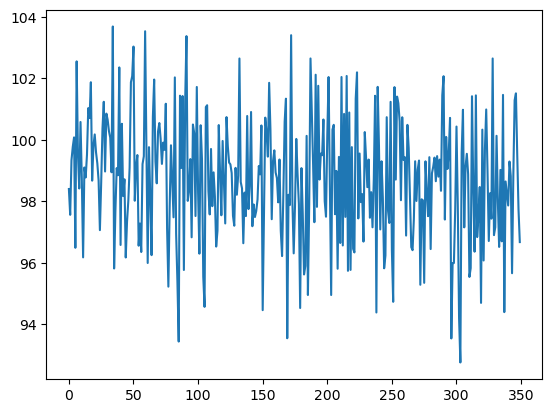

In [17]:
plt.plot(training_losses)